`Titanic Dataset Meets Unsupervised Learning`

#Part 1: Data Exploration
Tasks:
i. Load the dataset in python.
ii. Remove the Survived column - We'll start unsupervised
iii. Visualize distributions of Age, Fare, and Class
Discuss: What Patterns do we notice?

#Part 2: Clustering
Goal - Group passengers by similarity.
Steps:
i. Apply K-Means clustering (k=3).
ii. Label clusters and interpret them:
    a. Cluster 1: Wealthy first-class travelers
    b. Cluster 2: Families in steerage
    c. Cluster 3: Solo young adventurers
iii. Plot clusters using Age vs. Fare.
Discuss: Which cluster do we think had the highest survival rate?


#Part 3: Autoencoder Copression
Goal - Reduce data Complexity
Steps:
i. Build a simple Autoencoder with 3 layes.
ii. Encode features into a 2-D latent space.
iii. Visualize encoded data using a scatter plot.
Discuss: How does compression help us see relationships more clearly? 

#Part 4: Feature Discovery with RBM
Goal - Find hidden influences.
Steps:
i. Train a Restricted Boltzmann Machine on encoded data.
ii. Extract latent fetures (e.g., "Family influence","economic status").
iii. Add these features back to the dataset.
Discuss: What hidden factors might have affected survival?

#Part 5: Neural Network Prediction
Goal - Predict survival using discovered features.
Steps:
i. Add the survived column back.
ii. Train a Feedforward Neural Network.
iii. Evaluate accuracy and visualize predictions.
Discussion: How did unsupervised learning improve your neural network's performance?

## Part 1 : Data Exploration

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Display plots inside notebook
%matplotlib inline

# Better plot style
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Shape of Dataset: ",df.shape)
df.info()

Shape of Dataset:  (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Removed the target column (Survived)
#remove survived column
unsupervised_df = df.drop("Survived",axis=1)
unsupervised_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
#Check Missing Values
unsupervised_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# Fill Age with median
unsupervised_df["Age"] = unsupervised_df["Age"].fillna(
    unsupervised_df["Age"].median()
)

In [9]:
# Fill Embarked with mode
unsupervised_df["Embarked"] = unsupervised_df["Embarked"].fillna(
    unsupervised_df["Embarked"].mode()[0]
)

In [10]:
# Drop Cabin because it has too many missing values
unsupervised_df = unsupervised_df.drop(columns=["Cabin"])

Visualize of Part 1

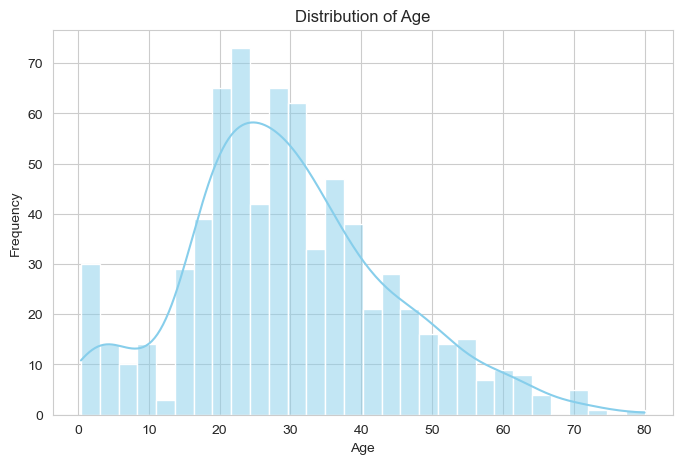

In [11]:
# Age distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

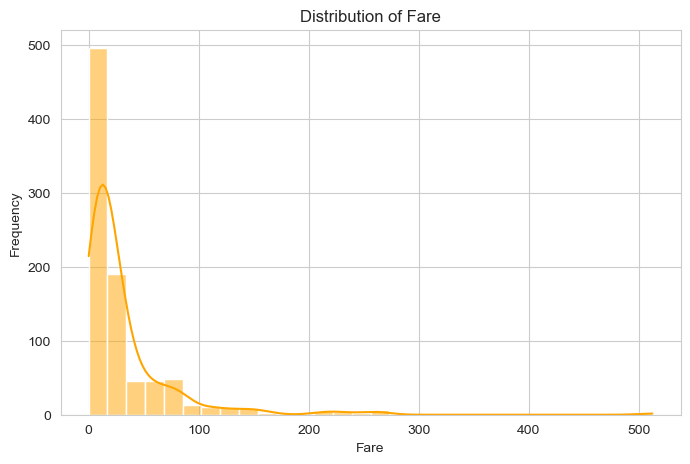

In [12]:
# Fare Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True, color="orange")

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

C:\Users\Manish Giri\AppData\Local\Temp\ipykernel_25148\1044660984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=df, palette="viridis")


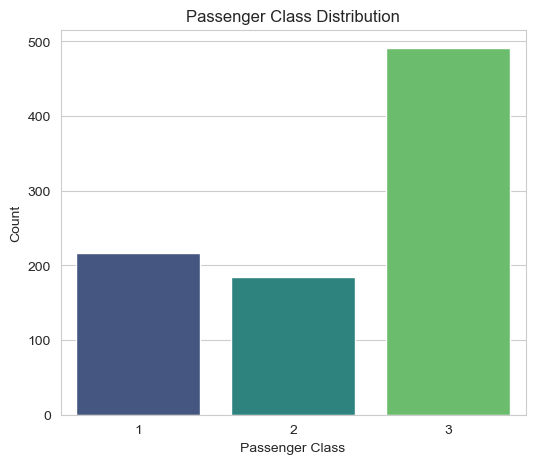

In [13]:
# Passenger Class Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="Pclass", data=df, palette="viridis")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

In [14]:
# Summary Stats
df[["Age","Fare","Pclass"]].describe()

,Age,Fare,Pclass
count,714.000000,891.000000,891.000000
mean,29.699118,32.204208,2.308642
std,14.526497,49.693429,0.836071
min,0.420000,0.000000,1.000000
25%,20.125000,7.910400,2.000000
50%,28.000000,14.454200,3.000000
75%,38.000000,31.000000,3.000000
max,80.000000,512.329200,3.000000


#Discussion Answer:
- Age: Most passengers were between 20–40 years old, with some missing values.
- Fare: Fare distribution is right-skewed; most passengers paid low fares, while a few paid very high fares (outliers).
- Passenger Class: Third Class (Pclass = 3) had the highest number of passengers, followed by Second and First Class.
- Overall: The data is imbalanced, contains missing values (Age), and includes outliers (Fare). The Survived column has been removed, making the dataset suitable for unsupervised learning.

# Part 2 : Clustering

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Select Features

In [16]:
# Select numerical features
cluster_df = df[["Age", "Fare", "Pclass"]].copy()

# Fill missing Age values
cluster_df["Age"] = cluster_df["Age"].fillna(cluster_df["Age"].median())

cluster_df.head()

,Age,Fare,Pclass
0,22.0,7.2500,3
1,38.0,71.2833,1
2,26.0,7.9250,3
3,35.0,53.1000,1
4,35.0,8.0500,3


Feature Scaling

In [17]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

apply K-Means k=3

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_df.head()

c:\Users\Manish Giri\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Age,Fare,Pclass,Cluster
0,22.0,7.2500,3,0
1,38.0,71.2833,1,1
2,26.0,7.9250,3,2
3,35.0,53.1000,1,1
4,35.0,8.0500,3,2


In [19]:
#Cluster summary
cluster_df.groupby("Cluster")[["Age", "Fare", "Pclass"]].mean()

,Age,Fare,Pclass
Cluster,,,
0,14.594952,16.971435,2.802885
1,36.888273,83.765511,1.018182
2,32.419006,14.547469,2.699784


Rename Clusters

In [20]:
cluster_names = {
    0: "Wealthy First-Class Travelers",
    1: "Families in Steerage",
    2: "Solo Young Adventurers"
}

cluster_df["Cluster_Name"] = cluster_df["Cluster"].map(cluster_names)

cluster_df.head()

,Age,Fare,Pclass,Cluster,Cluster_Name
0,22.0,7.2500,3,0,Wealthy First-Class Travelers
1,38.0,71.2833,1,1,Families in Steerage
2,26.0,7.9250,3,2,Solo Young Adventurers
3,35.0,53.1000,1,1,Families in Steerage
4,35.0,8.0500,3,2,Solo Young Adventurers


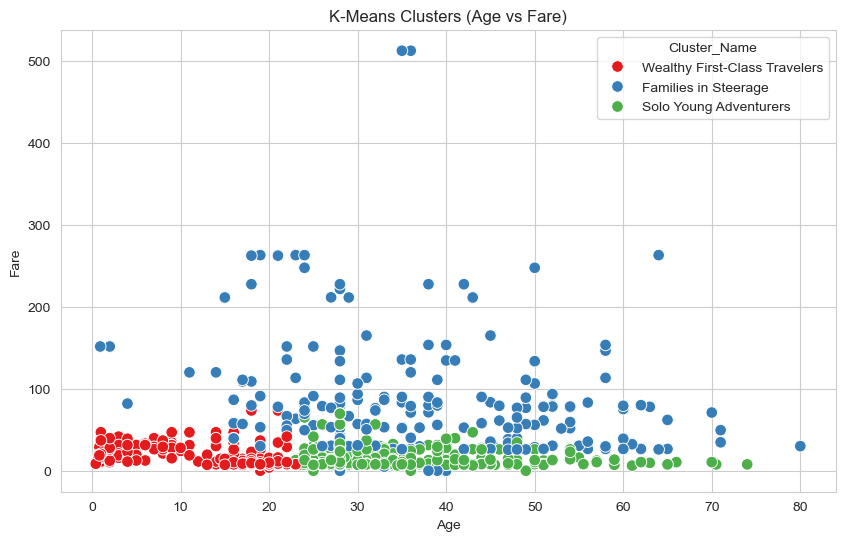

In [21]:
#plot Clusters (Age vs Fare)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cluster_df,
    x="Age",
    y="Fare",
    hue="Cluster_Name",
    palette="Set1",
    s=70
)

plt.title("K-Means Clusters (Age vs Fare)")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [22]:
#Number of Passanger in Each Cluster
print("No of passengers in Each Cluster:")
cluster_df["Cluster_Name"].value_counts()

No of passengers in Each Cluster:


Cluster_Name
Solo Young Adventurers           463
Families in Steerage             220
Wealthy First-Class Travelers    208
Name: count, dtype: int64

#Discussion Answer:
Cluster 1 (Wealthy First-Class Travelers) likely had the highest survival rate, because first-class passengers generally had better access to lifeboats and higher survival rates than second- and third-class passengers on the Titanic.

# Part 3 : Autoencoder Copression

In [23]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

Prepare the Data

In [ ]:
#Select features
auto_df = df[['Age','Fare','Pclass']].copy()
auto_df.isna().sum()

Age       177
Fare        0
Pclass      0
dtype: int64

In [25]:
#Fill missing Age values
auto_df['Age'] = auto_df['Age'].fillna(auto_df['Age'].median())

In [26]:
auto_df.isna().sum()

Age       0
Fare      0
Pclass    0
dtype: int64

In [27]:
#Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(auto_df)
print(X.shape)

(891, 3)


Build a Simple 3-Layer Autoencoder [ Input(3) -> Latent(2) -> Output(3)]

In [28]:
#Input Layer
input_layer = Input(shape=(3,))

#Encoder (Latent Shape)
encoder = Dense(2, activation='relu')(input_layer)

#Decoder
decoder = Dense(3, activation='linear')(encoder)

#Autoencoder Model
autoencoder = Model(input_layer, decoder)

#Encoder Model
encoder = Model(input_layer, encoder)

#compile
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

#summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Train the Autoencoder
history = autoencoder.fit(
    X,
    X,
    epochs = 100,
    batch_size = 32,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4875 - val_loss: 1.4556
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3948 - val_loss: 1.3782
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3205 - val_loss: 1.3155
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2596 - val_loss: 1.2644
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2113 - val_loss: 1.2216
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1701 - val_loss: 1.1874
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1360 - val_loss: 1.1579
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1076 - val_loss: 1.1331
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0832 - val_loss: 1.1115
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0619 - val_loss: 1.0932
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0433 - val_loss: 1.0771
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.

In [31]:
#Encode into 2-D Latent Space
encoded_data = encoder.predict(X)
print(encoded_data)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[[1.4232844  0.        ]
 [0.         1.3439981 ]
 [1.1670227  0.        ]
 ...
 [0.944132   0.        ]
 [0.43972152 0.7587719 ]
 [0.7900396  0.        ]]


Visualization

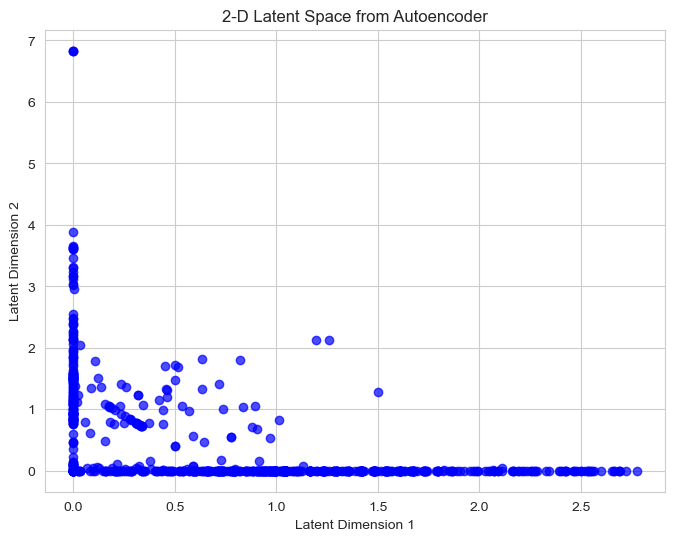

In [32]:
# Visualize Encoded Data
plt.figure(figsize=(8,6))

plt.scatter(
    encoded_data[:,0],
    encoded_data[:,1],
    alpha=0.7,
    c='blue'
)

plt.title("2-D Latent Space from Autoencoder")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.show()

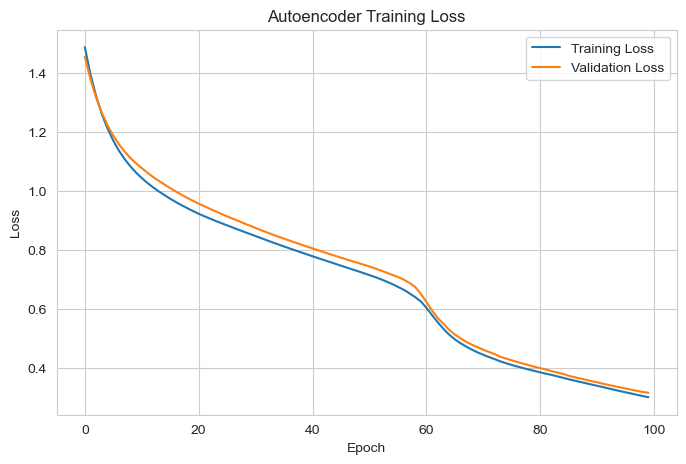

In [33]:
#Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")

plt.legend()

plt.show()

#Discussion Answer:
- The autoencoder compresses the original 3 features into 2 latent features while preserving important information.
- Compression removes redundant information and captures the most meaningful patterns.
- The 2-D scatter plot makes it easier to identify similar passengers and possible groups.
- Low-dimensional representations simplify visualization and can improve clustering and pattern discovery.

# Part 4 : Feature Discovery with RBM (Restricted Boltzmann Machine)

In [35]:
from sklearn.neural_network import BernoulliRBM

In [37]:
#Train the RBM
#Create RBM model
rbm = BernoulliRBM(
    n_components=2,
    learning_rate=0.01,
    batch_size=10,
    n_iter=50,
    random_state=42
)
#Train on encoded data
rbm.fit(encoded_data)

BernoulliRBM(learning_rate=0.01, n_components=2, n_iter=50, random_state=42)

In [38]:
#Extract Latent Features
#Transform encoded data into hidden features
rbm_features = rbm.transform(encoded_data)
print(rbm_features.shape)

(891, 2)


In [39]:
#Add Hidden Features to Dataset
#add RBM feature to original dataframe
df['Family_Influence'] = rbm_features[:,0]
df['Economic_Status'] = rbm_features[:,1]

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Influence,Economic_Status
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.952322,0.951217
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.003915,0.004110
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.884694,0.882847
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.007008,0.007305
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.479355,0.478240


In [40]:
#View new Features
df[['Family_Influence', 'Economic_Status']].describe()

,Family_Influence,Economic_Status
count,8.910000e+02,8.910000e+02
mean,5.296488e-01,5.290118e-01
std,3.942204e-01,3.933956e-01
min,7.646570e-09,9.423092e-09
25%,7.916840e-02,8.000439e-02
50%,6.572668e-01,6.552039e-01
75%,9.005042e-01,8.987866e-01
max,9.996784e-01,9.996598e-01


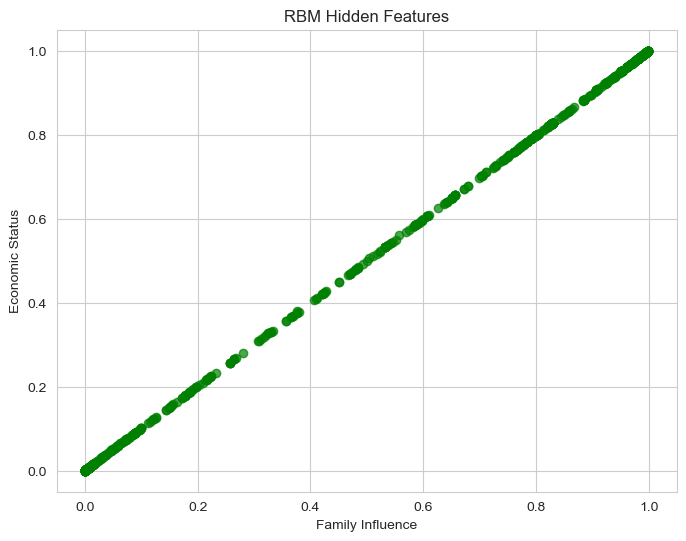

In [41]:
#Visualize Hidden Features
plt.figure(figsize=(8,6))

plt.scatter(
    df["Family_Influence"],
    df["Economic_Status"],
    alpha=0.7,
    color="green"
)

plt.title("RBM Hidden Features")
plt.xlabel("Family Influence")
plt.ylabel("Economic Status")

plt.show()

#Discussion Answer:
- RBM discovers hidden patterns that are not directly visible in the original features.
- The hidden features may represent family influence, economic status, or other underlying passenger characteristics.
- These latent factors can help explain differences in passenger behavior and survival chances.
- Higher economic status and stronger family-related patterns may have increased the likelihood of survival during the Titanic disaster.

# Part 5 : Neural Network Prediction

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Prepare Features and Target

In [43]:
#Select features including RBM features
X = df[['Age', 'Fare','Pclass','Family_Influence','Economic_Status']].copy()

In [44]:
X.isna().sum()

Age                 177
Fare                  0
Pclass                0
Family_Influence      0
Economic_Status       0
dtype: int64

In [45]:
#Fill the missing Age values
X['Age'] = X['Age'].fillna(X['Age'].median())

In [46]:
#Target Feature
y = df['Survived']

Feature Scalling

In [ ]:
X_scaled = scaler.fit_transform(X)

Split the Dataset

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Build Feedforward Neural Network

In [53]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(5,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

c:\Users\Manish Giri\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

Train the model

In [54]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6169 - loss: 0.7223 - val_accuracy: 0.6503 - val_loss: 0.6628
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6169 - loss: 0.6846 - val_accuracy: 0.6503 - val_loss: 0.6436
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6169 - loss: 0.6601 - val_accuracy: 0.6503 - val_loss: 0.6312
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6169 - loss: 0.6475 - val_accuracy: 0.6503 - val_loss: 0.6226
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6186 - loss: 0.6362 - val_accuracy: 0.6503 - val_loss: 0.6165
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6169 - loss: 0.6272 - val_accuracy: 0.6573 - val_loss: 0.6115
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6380 - loss: 0.6204 - val_accuracy: 0.6783 - val_loss: 0.6079
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6520 - loss: 0.6145 - val_accuracy: 0.6783 - val_loss

Evaluate model

In [55]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: ",round(accuracy*100,2),"%")

Test Accuracy:  75.42 %


Prediction

In [56]:
y_pred = model.predict(X_test)

#convert probabilities into class labels
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy: ",accuracy_score(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Accuracy:  0.7541899441340782


Confusion Matrix

In [58]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[94 11]
 [33 41]]


Classification Report

In [59]:
print("Classification Report: \n",classification_report(y_test, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.74      0.90      0.81       105
           1       0.79      0.55      0.65        74

    accuracy                           0.75       179
   macro avg       0.76      0.72      0.73       179
weighted avg       0.76      0.75      0.74       179



Visualize

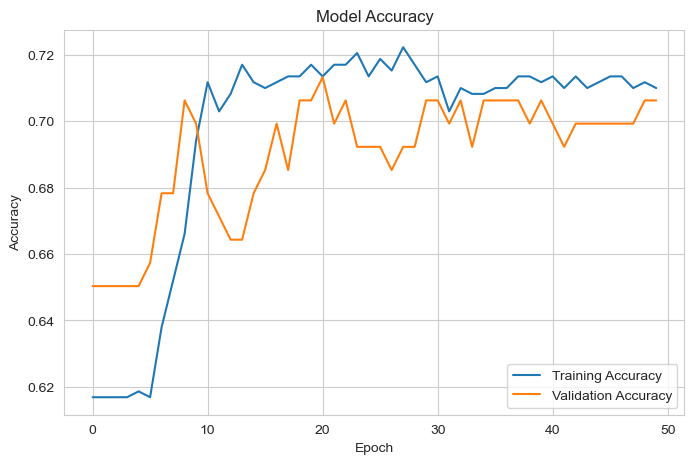

In [60]:
#Plot Training Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()

plt.show()

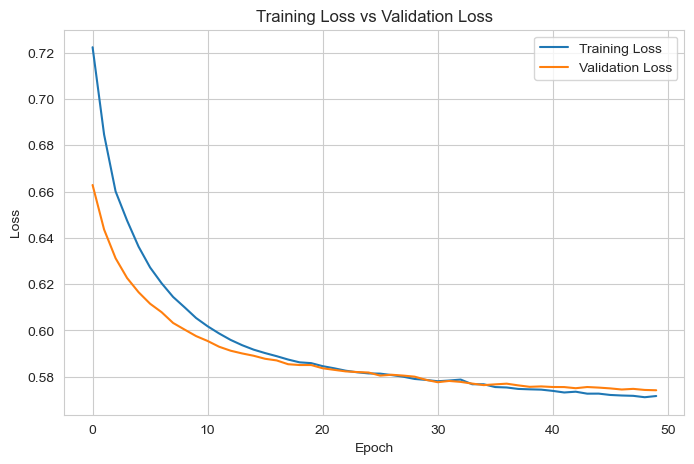

In [62]:
# Plot Training Loss and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

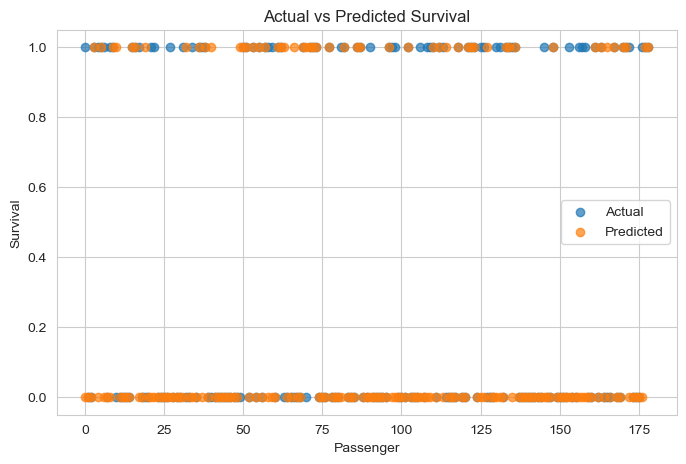

In [ ]:
# Visualize Actual vs Predicted
plt.figure(figsize=(8,5))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual",
    alpha=0.7
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    alpha=0.7
)

plt.xlabel("Passenger")
plt.ylabel("Survival")

plt.title("Actual vs Predicted Survival")

plt.legend()

plt.show()

#Discussion Answer:
- Unsupervised learning (Autoencoder and RBM) extracted hidden patterns from the data before classification.
- The discovered latent features captured relationships that were not directly visible in the original features.
- These additional features provided more informative inputs to the neural network.
- As a result, the model can achieve better prediction accuracy and generalize more effectively compared to using only the original features.